# Dataset Preprocessing
Prepares the Bonn EEG, MIT-BIH, and ECG5000 datasets for the early-exit experiments.
Each dataset gets scaled, reshaped to `(N, 1, timesteps)`, and split 70/15/15.

In [1]:
import numpy as np
import pandas as pd
import os
import zipfile
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

---
## Bonn EEG Dataset

In [2]:
RAW_DIR = './data/bonn_raw'
BONN_OUTPUT = './data/bonn'
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(BONN_OUTPUT, exist_ok=True)

# Check if data already exists locally; download only if missing
existing_folders = [d for d in ['F', 'N', 'O', 'S', 'Z']
                    if os.path.isdir(os.path.join(RAW_DIR, d))]
if len(existing_folders) == 5:
    print('Bonn raw data already present, skipping download.')
else:
    import gdown
    gdown.download_folder(
        'https://drive.google.com/drive/folders/1R3_mRvKdsW4zw8NSmr7UlSw_zcf2Sz9H',
        output=RAW_DIR, quiet=False
    )
    for zf in glob.glob(os.path.join(RAW_DIR, '*.zip')):
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(RAW_DIR)

for folder in ['F', 'N', 'O', 'S', 'Z']:
    path = os.path.join(RAW_DIR, folder)
    if os.path.exists(path):
        n_files = len([f for f in os.listdir(path) if f.lower().endswith('.txt')])
        print(f'  {folder}: {n_files} files')
    else:
        print(f'  {folder}: NOT FOUND')

Bonn raw data already present, skipping download.
  F: 100 files
  N: 100 files
  O: 100 files
  S: 100 files
  Z: 100 files


In [3]:
data = []
labels = []
SEIZURE_FOLDER = 'Z'
folders = ['F', 'N', 'O', 'S', 'Z']

for folder in folders:
    folder_path = os.path.join(RAW_DIR, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.txt')])
    for file in files:
        signal = np.loadtxt(os.path.join(folder_path, file))
        label = 1 if folder == SEIZURE_FOLDER else 0
        data.append(signal)
        labels.append(label)
    print(f'  {folder}: {len(files)} files | label={1 if folder == SEIZURE_FOLDER else 0}')

X = np.array(data, dtype=np.float32)
y = np.array(labels, dtype=np.int64)
print(f'\nShape: {X.shape}')
print(pd.Series(y, name='label').value_counts().rename({0: 'Non-Seizure', 1: 'Seizure'}))

  F: 100 files | label=0
  N: 100 files | label=0
  O: 100 files | label=0
  S: 100 files | label=0
  Z: 100 files | label=1

Shape: (500, 4097)
label
Non-Seizure    400
Seizure        100
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Before: mean={X.mean():.4f}, std={X.std():.4f}')
print(f'After:  mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}')

X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])
print(f'CNN shape: {X_scaled.shape}')

Before: mean=-7.7212, std=164.5897
After:  mean=-0.0000, std=1.0000
CNN shape: (500, 1, 4097)


In [5]:
seizure_idx = np.where(y == 1)[0]
non_seizure_idx = np.where(y == 0)[0]

n_non_seizure_keep = min(len(non_seizure_idx), len(seizure_idx) * 3)
non_seizure_sampled = np.random.choice(non_seizure_idx, n_non_seizure_keep, replace=False)
balanced_idx = np.concatenate([seizure_idx, non_seizure_sampled])
np.random.shuffle(balanced_idx)

X_balanced = X_scaled[balanced_idx]
y_balanced = y[balanced_idx]
print(pd.Series(y_balanced, name='label').value_counts().rename({0: 'Non-Seizure', 1: 'Seizure'}))

label
Non-Seizure    300
Seizure        100
Name: count, dtype: int64


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test),
                   ('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    np.save(os.path.join(BONN_OUTPUT, f'{name}.npy'), arr)

print(f'Saved to {BONN_OUTPUT}')

Train: (280, 1, 4097)  Val: (60, 1, 4097)  Test: (60, 1, 4097)
Saved to ./data/bonn


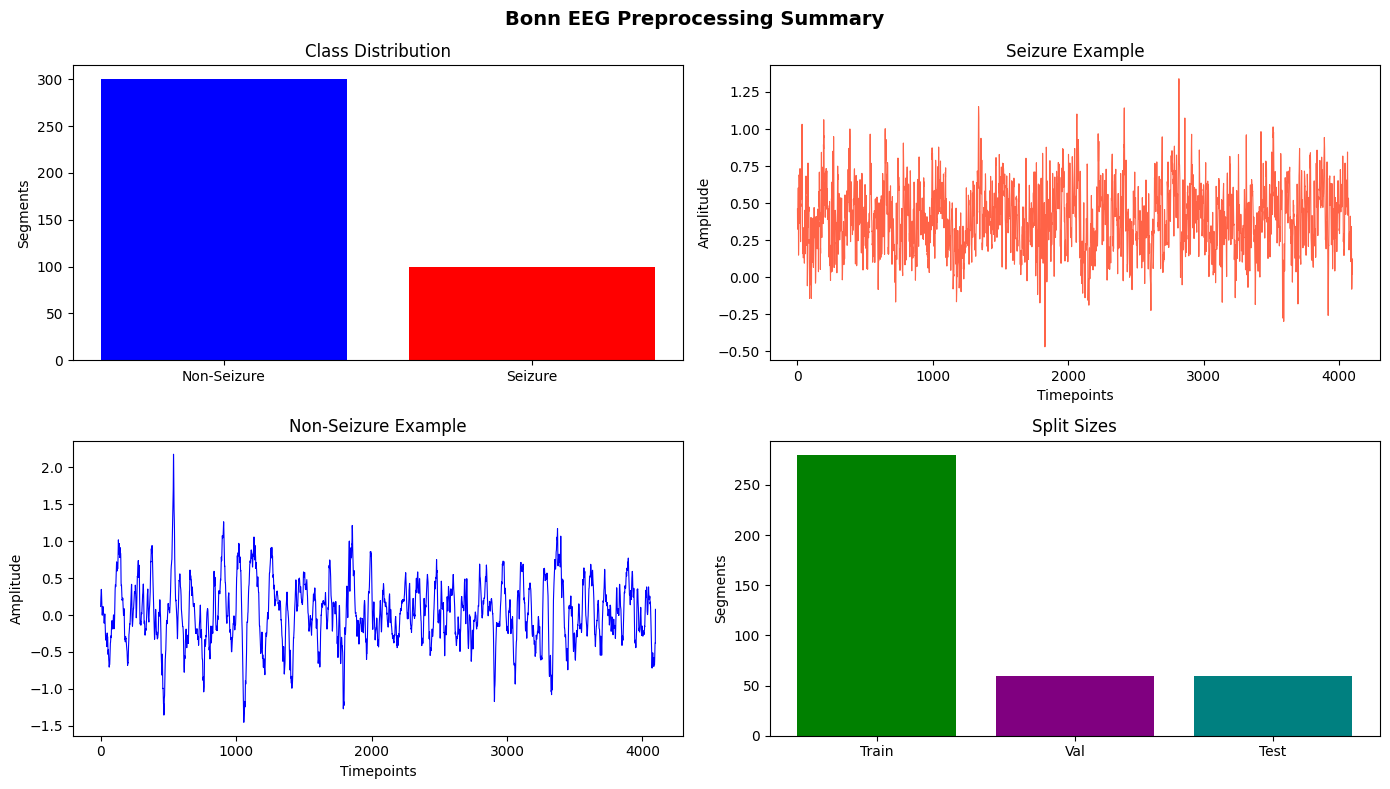

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Bonn EEG Preprocessing Summary', fontsize=14, fontweight='bold')

axes[0,0].bar(['Non-Seizure', 'Seizure'],
               [(y_balanced==0).sum(), y_balanced.sum()],
               color=['blue', 'red'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Segments')

axes[0,1].plot(X_balanced[y_balanced == 1][0][0], color='tomato', linewidth=0.8)
axes[0,1].set_title('Seizure Example')
axes[0,1].set_xlabel('Timepoints')
axes[0,1].set_ylabel('Amplitude')

axes[1,0].plot(X_balanced[y_balanced == 0][0][0], color='blue', linewidth=0.8)
axes[1,0].set_title('Non-Seizure Example')
axes[1,0].set_xlabel('Timepoints')
axes[1,0].set_ylabel('Amplitude')

axes[1,1].bar(['Train', 'Val', 'Test'],
               [len(X_train), len(X_val), len(X_test)],
               color=['green', 'purple', 'teal'])
axes[1,1].set_title('Split Sizes')
axes[1,1].set_ylabel('Segments')

plt.tight_layout()
plt.savefig(os.path.join(BONN_OUTPUT, 'bonn_preprocessing_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## MIT-BIH Heartbeat Dataset

In [8]:
import kagglehub

MIT_OUTPUT = './data/mitbih'
os.makedirs(MIT_OUTPUT, exist_ok=True)

path = kagglehub.dataset_download('shayanfazeli/heartbeat')
print(f'Downloaded to: {path}')

all_csv = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            all_csv.append(os.path.join(root, f))

train_csv = [f for f in all_csv if 'mitbih_train' in f.lower()][0]
test_csv = [f for f in all_csv if 'mitbih_test' in f.lower()][0]

df_train = pd.read_csv(train_csv, header=None)
df_test = pd.read_csv(test_csv, header=None)
df_mit = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

X_mit = df_mit.iloc[:, :-1].values.astype(np.float32)
y_mit = df_mit.iloc[:, -1].values.astype(np.int64)

print(f'Features: {X_mit.shape}  Labels: {y_mit.shape}')
print(pd.Series(y_mit).value_counts().sort_index())

/Users/surya/Downloads/Early_exit_architecture_research/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: /Users/surya/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1
Features: (109446, 187)  Labels: (109446,)
0    90589
1     2779
2     7236
3      803
4     8039
Name: count, dtype: int64


In [9]:
scaler_mit = StandardScaler()
X_mit_scaled = scaler_mit.fit_transform(X_mit)
X_mit_reshaped = X_mit_scaled.reshape(X_mit_scaled.shape[0], 1, X_mit_scaled.shape[1])
print(f'CNN shape: {X_mit_reshaped.shape}')

X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(
    X_mit_reshaped, y_mit, test_size=0.3, random_state=42, stratify=y_mit
)
X_val_m, X_test_m, y_val_m, y_test_m = train_test_split(
    X_temp_m, y_temp_m, test_size=0.5, random_state=42, stratify=y_temp_m
)

print(f'Train: {X_train_m.shape}  Val: {X_val_m.shape}  Test: {X_test_m.shape}')

for name, arr in [('X_train', X_train_m), ('X_val', X_val_m), ('X_test', X_test_m),
                   ('y_train', y_train_m), ('y_val', y_val_m), ('y_test', y_test_m)]:
    np.save(os.path.join(MIT_OUTPUT, f'{name}.npy'), arr)

print(f'Saved to {MIT_OUTPUT}')

CNN shape: (109446, 1, 187)
Train: (76612, 1, 187)  Val: (16417, 1, 187)  Test: (16417, 1, 187)
Saved to ./data/mitbih


---
## ECG5000 Dataset

In [10]:
ECG_OUTPUT = './data/ecg'
os.makedirs(ECG_OUTPUT, exist_ok=True)

path_ecg = kagglehub.dataset_download('salsabilahmid/ecg50000')
print(f'Downloaded to: {path_ecg}')

all_files = []
for root, dirs, files in os.walk(path_ecg):
    for f in files:
        if f.endswith('.csv') or f.endswith('.txt'):
            all_files.append(os.path.join(root, f))

dfs = []
for f in sorted(all_files):
    df = pd.read_csv(f, header=None, sep=r'\s+')
    # Drop any rows that contain non-numeric values (header rows)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    print(f'  {os.path.basename(f)}: {df.shape}')
    dfs.append(df)

df_ecg = pd.concat(dfs, axis=0).reset_index(drop=True)
print(f'Combined shape: {df_ecg.shape}')

# ECG5000: first column is the label (1-5), remaining 140 columns are features
y_ecg = df_ecg.iloc[:, 0].values.astype(np.int64)
X_ecg = df_ecg.iloc[:, 1:].values.astype(np.float32)
y_ecg = y_ecg - y_ecg.min()  # shift to 0-indexed

print(f'Features: {X_ecg.shape}  Labels: {y_ecg.shape}')
print(pd.Series(y_ecg).value_counts().sort_index())

Downloaded to: /Users/surya/.cache/kagglehub/datasets/salsabilahmid/ecg50000/versions/1
  ECG5000.txt: (0, 5)
  ECG5000_TEST.txt: (4500, 141)
  ECG5000_TRAIN.txt: (500, 141)
Combined shape: (5000, 141)
Features: (5000, 140)  Labels: (5000,)
0    2919
1    1767
2      96
3     194
4      24
Name: count, dtype: int64


In [11]:
scaler_ecg = StandardScaler()
X_ecg_scaled = scaler_ecg.fit_transform(X_ecg)
X_ecg_reshaped = X_ecg_scaled.reshape(X_ecg_scaled.shape[0], 1, X_ecg_scaled.shape[1])
print(f'CNN shape: {X_ecg_reshaped.shape}')

X_train_e, X_temp_e, y_train_e, y_temp_e = train_test_split(
    X_ecg_reshaped, y_ecg, test_size=0.3, random_state=42, stratify=y_ecg
)
X_val_e, X_test_e, y_val_e, y_test_e = train_test_split(
    X_temp_e, y_temp_e, test_size=0.5, random_state=42, stratify=y_temp_e
)

print(f'Train: {X_train_e.shape}  Val: {X_val_e.shape}  Test: {X_test_e.shape}')

for name, arr in [('X_train', X_train_e), ('X_val', X_val_e), ('X_test', X_test_e),
                   ('y_train', y_train_e), ('y_val', y_val_e), ('y_test', y_test_e)]:
    np.save(os.path.join(ECG_OUTPUT, f'{name}.npy'), arr)

print(f'Saved to {ECG_OUTPUT}')

CNN shape: (109446, 1, 187)
Train: (76612, 1, 187)  Val: (16417, 1, 187)  Test: (16417, 1, 187)
Saved to ./data/mitbih


In [12]:
print('All datasets processed.')
for name, path in [('Bonn', BONN_OUTPUT), ('MIT-BIH', MIT_OUTPUT), ('ECG', ECG_OUTPUT)]:
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    total_mb = sum(os.path.getsize(os.path.join(path, f)) for f in files) / 1e6
    print(f'  {name}: {len(files)} files, {total_mb:.1f} MB')

All datasets processed.
  Bonn: 6 files, 6.6 MB
  MIT-BIH: 6 files, 82.7 MB
  ECG: 6 files, 93.7 MB
